# Tutorial 2b: Spatial Visualization of Compositionally Diverse Samples

**Systems Biology — Spatial Proteomics Module**

## Purpose

This notebook visualises the **15 most compositionally diverse IMC images** identified by `analyze_sample_variability.py` — the top 3 per cancer indication (BREAS, GI, GU, HN, THOR), ranked by:

$$\text{composite score} = \underbrace{H(p)}_{\text{Shannon entropy}} \times \underbrace{(1 - p_{\text{tumor}})}_{\text{immune infiltration}}$$

These samples were chosen **specifically to avoid pure-tumor slides** and to showcase rich immune microenvironments suitable for spatial interaction analysis.

## What you will see
1. **Per-image scatter plots** — each cell plotted at its physical X/Y coordinates, coloured by cell type
2. **Per-indication panels** — all 3 ranked images side-by-side for each cancer type
3. **Composition bar charts** — cell-type proportions alongside each spatial map
4. **Cross-indication overview** — the #1 pick from each cancer type on one page

---

In [1]:
import json
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams['figure.dpi'] = 110
sns.set_style('white')

DATA_PATH    = 'data/train_adata.h5ad'
SAMPLES_PATH = 'data/diverse_samples_per_indication.json'

---
## Part 1: Load Data and Curated Sample List

In [2]:
print('Loading AnnData...')
adata = ad.read_h5ad(DATA_PATH)
if 'exprs_arcsinh' not in adata.layers:
    adata.layers['exprs_arcsinh'] = np.arcsinh(adata.layers['exprs'] / 5)
print(f'  {adata.n_obs:,} cells  |  {adata.obs["image"].nunique()} images')

with open(SAMPLES_PATH) as f:
    diverse_samples = json.load(f)

flat_samples = [
    (ind, entry['rank'], entry)
    for ind, entries in diverse_samples.items()
    for entry in entries
]

print(f'\nCurated samples: {len(flat_samples)} images across {len(diverse_samples)} indications')
print(f'{"Ind":<6} {"Rank":<5} {"Cells":>6} {"Tumor":>7} {"Entropy":>8} {"Composite":>10}  Sample')
print('-' * 90)
for ind, rank, e in flat_samples:
    short = ('...' + e['image'][-37:]) if len(e['image']) > 40 else e['image']
    print(f'{ind:<6} #{rank:<4} {e["n_cells"]:>6} {e["tumor_prop"]:>7.1%} '
          f'{e["shannon_entropy"]:>8.3f} {e["composite_score"]:>10.3f}  {short}')

Loading AnnData...


  253,433 cells  |  132 images

Curated samples: 15 images across 5 indications
Ind    Rank   Cells   Tumor  Entropy  Composite  Sample
------------------------------------------------------------------------------------------
BREAS  #1       563    1.4%    2.064      2.035  ...2131-SPECT-VAR-TIS-01-IMC-01_001.tiff
BREAS  #2      1358   14.8%    2.257      1.923  ...5014-SPECT-VAR-TIS-01-IMC-01_002.tiff
BREAS  #3      1775   10.5%    2.135      1.910  ...3153-SPECT-VAR-TIS-01-IMC-01_002.tiff
GI     #1      1540    2.1%    2.227      2.181  ..._10043241-GI-VAR-TIS-UNST-03_007.tiff
GI     #2      1641    0.2%    2.031      2.027  ...074350-SPECT-VAR-TIS-UNST-03_004.tiff
GI     #3      2672    1.0%    1.650      1.634  ...068187-SPECT-VAR-TIS-UNST-03_004.tiff
GU     #1      2340    2.0%    2.043      2.002  ...0037093-GU-VAR-TIS-01-IMC-01_004.tiff
GU     #2      1628    1.4%    1.817      1.793  ...0042702-GU-VAR-TIS-01-IMC-01_003.tiff
GU     #3       340    0.0%    1.491      1.491  ...8

---
## Part 2: Colour Palette for Cell Types

A consistent palette is critical — the same colour must mean the same cell type across all plots.

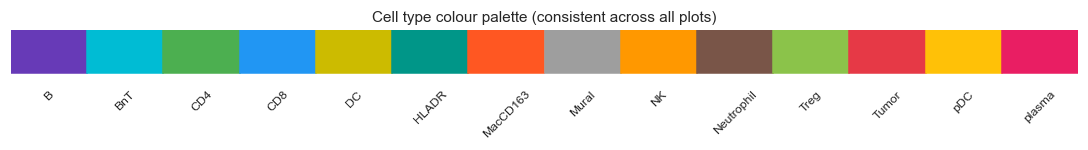

In [3]:
CELL_TYPES = sorted(adata.obs['celltypes'].unique().tolist())

MANUAL_COLORS = {
    'Tumor'    : '#E63946',
    'CD8'      : '#2196F3',
    'CD4'      : '#4CAF50',
    'Treg'     : '#8BC34A',
    'BnT'      : '#00BCD4',
    'B'        : '#673AB7',
    'NK'       : '#FF9800',
    'MacCD163' : '#FF5722',
    'Mural'    : '#9E9E9E',
    'DC'       : '#CCBB00',
    'pDC'      : '#FFC107',
    'HLADR'    : '#009688',
    'Neutrophil': '#795548',
    'plasma'   : '#E91E63',
}
extra_colors = sns.color_palette('tab20', 20)
extra_idx = 0
for ct in CELL_TYPES:
    if ct not in MANUAL_COLORS:
        MANUAL_COLORS[ct] = extra_colors[extra_idx]; extra_idx += 1
CT_PALETTE = {ct: MANUAL_COLORS[ct] for ct in CELL_TYPES}

fig, ax = plt.subplots(figsize=(10, 1.4))
for i, ct in enumerate(CELL_TYPES):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=CT_PALETTE[ct]))
    ax.text(i + 0.5, -0.35, ct, ha='center', va='top', fontsize=8, rotation=45)
ax.set_xlim(0, len(CELL_TYPES)); ax.set_ylim(-0.6, 1); ax.axis('off')
ax.set_title('Cell type colour palette (consistent across all plots)', fontsize=10)
plt.tight_layout()
plt.show()

---
## Part 3: Helper Functions

In [4]:
def plot_spatial_image(adata_img, ax, title='', show_legend=True, point_size=6):
    """Scatter cells at physical (Pos_X, Pos_Y) coloured by cell type."""
    obs = adata_img.obs
    for ct in obs['celltypes'].value_counts().index.tolist():
        mask = obs['celltypes'] == ct
        ax.scatter(obs.loc[mask, 'Pos_X'], obs.loc[mask, 'Pos_Y'],
                   c=CT_PALETTE.get(ct, '#cccccc'), s=point_size,
                   alpha=0.75, linewidths=0, label=ct, rasterized=True)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_xlabel('X (µm)', fontsize=8)
    ax.set_ylabel('Y (µm)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.set_title(title, fontsize=8, pad=4)
    if show_legend:
        cts_p = obs['celltypes'].value_counts().index.tolist()
        handles = [mpatches.Patch(color=CT_PALETTE[ct], label=ct) for ct in cts_p]
        ax.legend(handles=handles, fontsize=7, loc='upper right',
                  bbox_to_anchor=(1.0, 1.0), framealpha=0.7)


def plot_composition_bar(img, ax):
    """Horizontal bar of full cell-type proportions for one image."""
    obs_img = adata.obs[adata.obs['image'] == img]
    ct_counts = obs_img['celltypes'].value_counts()
    ct_props  = (ct_counts / ct_counts.sum()).sort_values(ascending=True)
    colors = [CT_PALETTE.get(ct, '#cccccc') for ct in ct_props.index]
    ax.barh(ct_props.index, ct_props.values, color=colors, edgecolor='white', linewidth=0.3)
    ax.set_xlabel('Proportion', fontsize=7)
    ax.tick_params(labelsize=7); ax.set_xlim(0, 1)
    for ct, val in ct_props.items():
        if val > 0.03:
            ax.text(val + 0.01, ct, f'{val:.0%}', va='center', fontsize=6)
    ax.set_title('Composition', fontsize=8)


print('Helper functions ready: plot_spatial_image(), plot_composition_bar()')

Helper functions ready: plot_spatial_image(), plot_composition_bar()


---
## Part 4: Per-Indication Panels (Top 3 Diverse Samples Each)

Each panel shows the spatial map (top row) and composition bar chart (bottom row).
Columns = rank #1, #2, #3 by composite score.

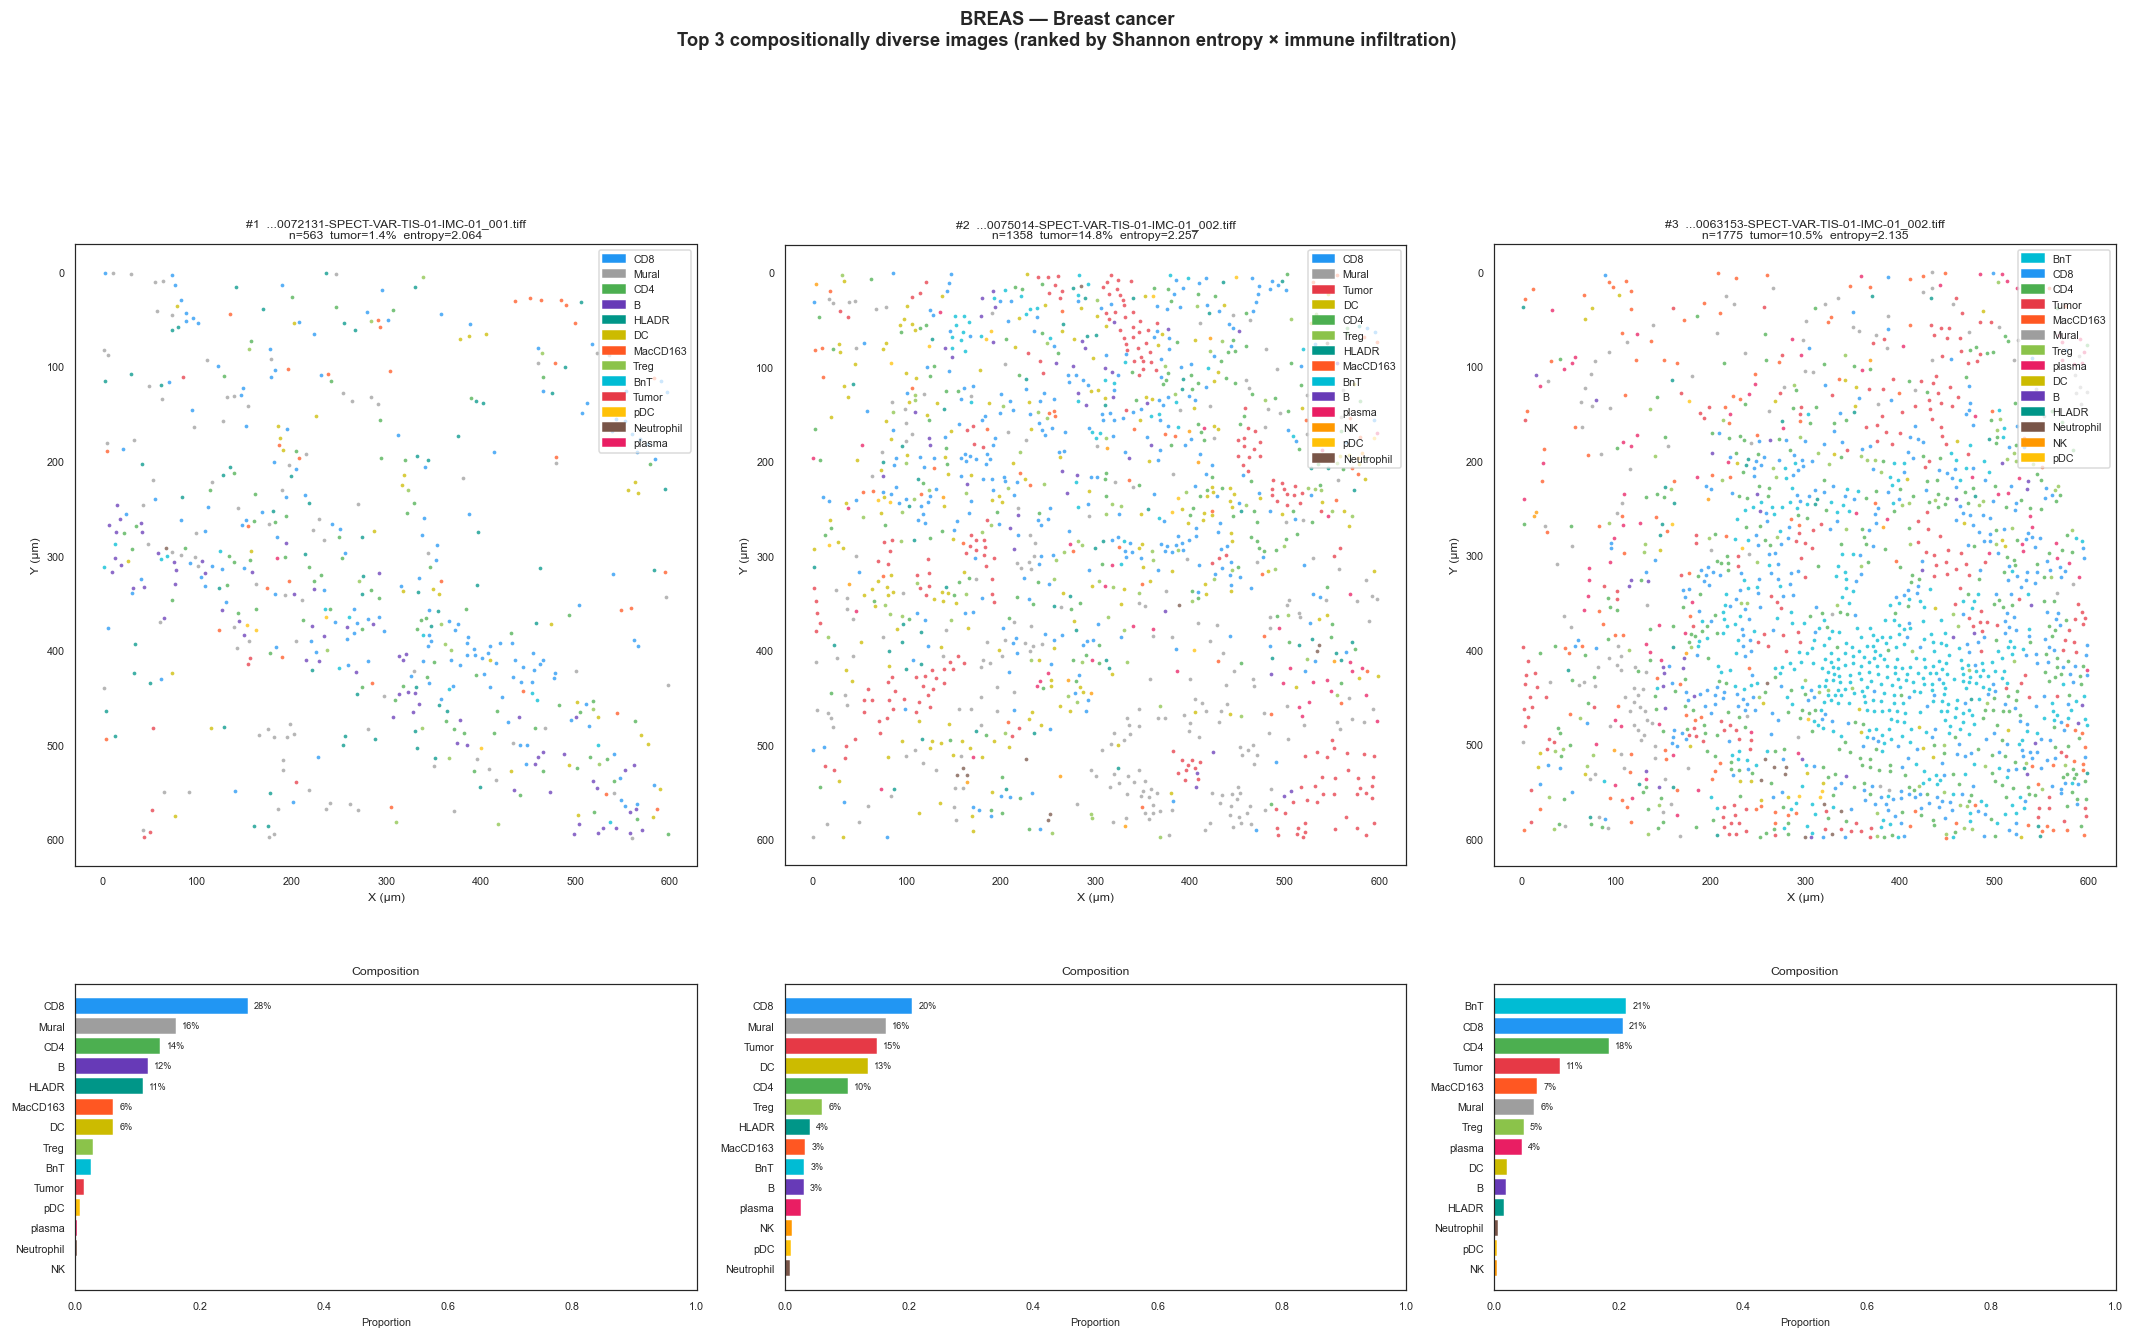

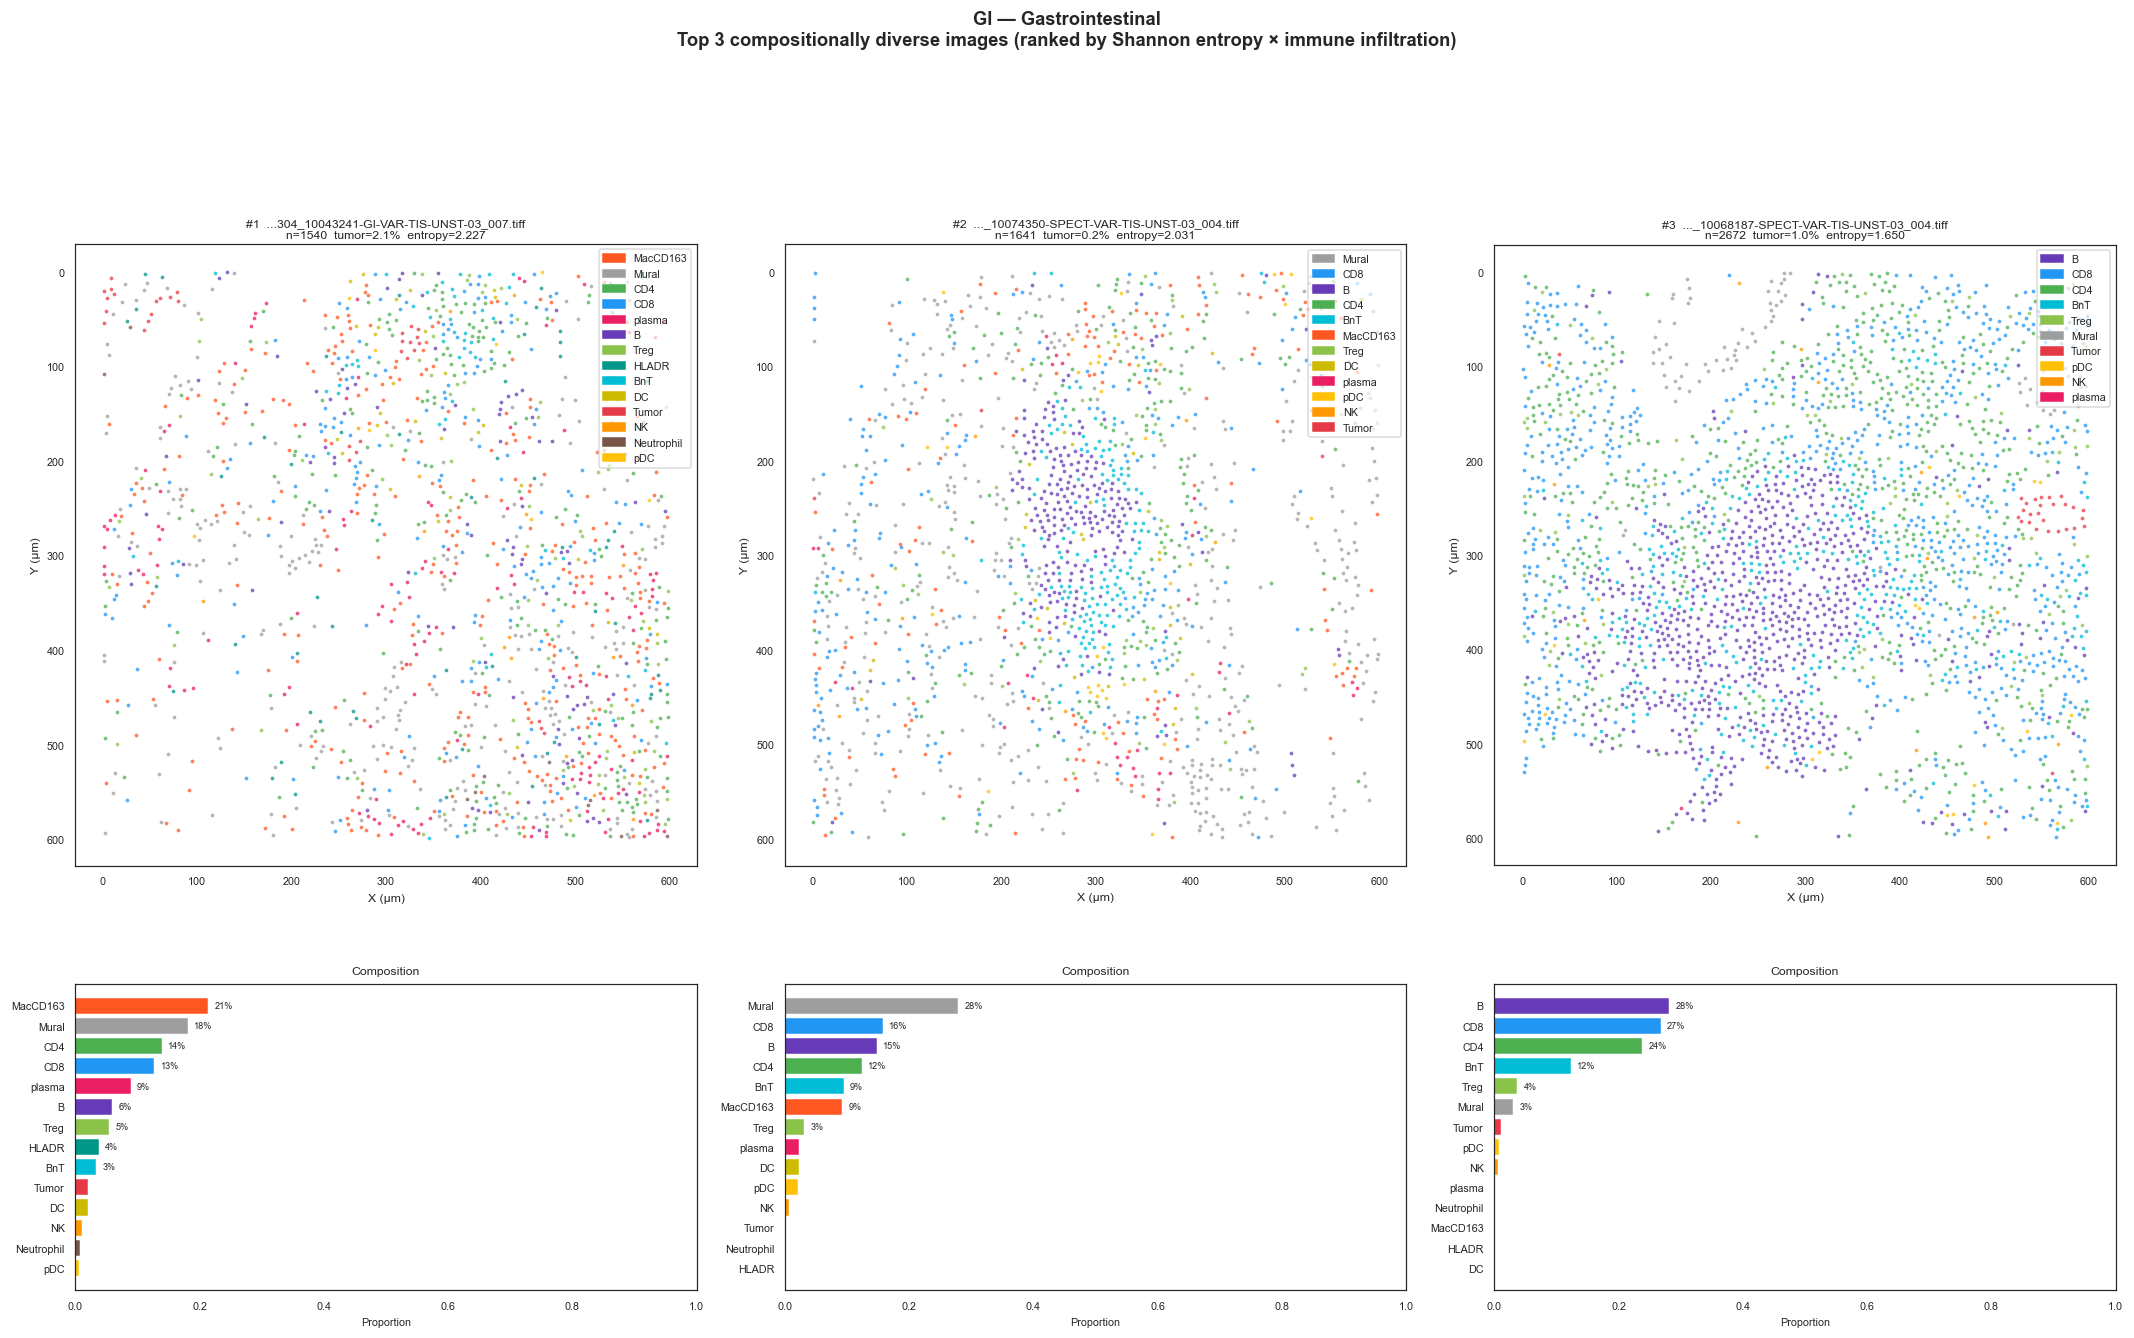

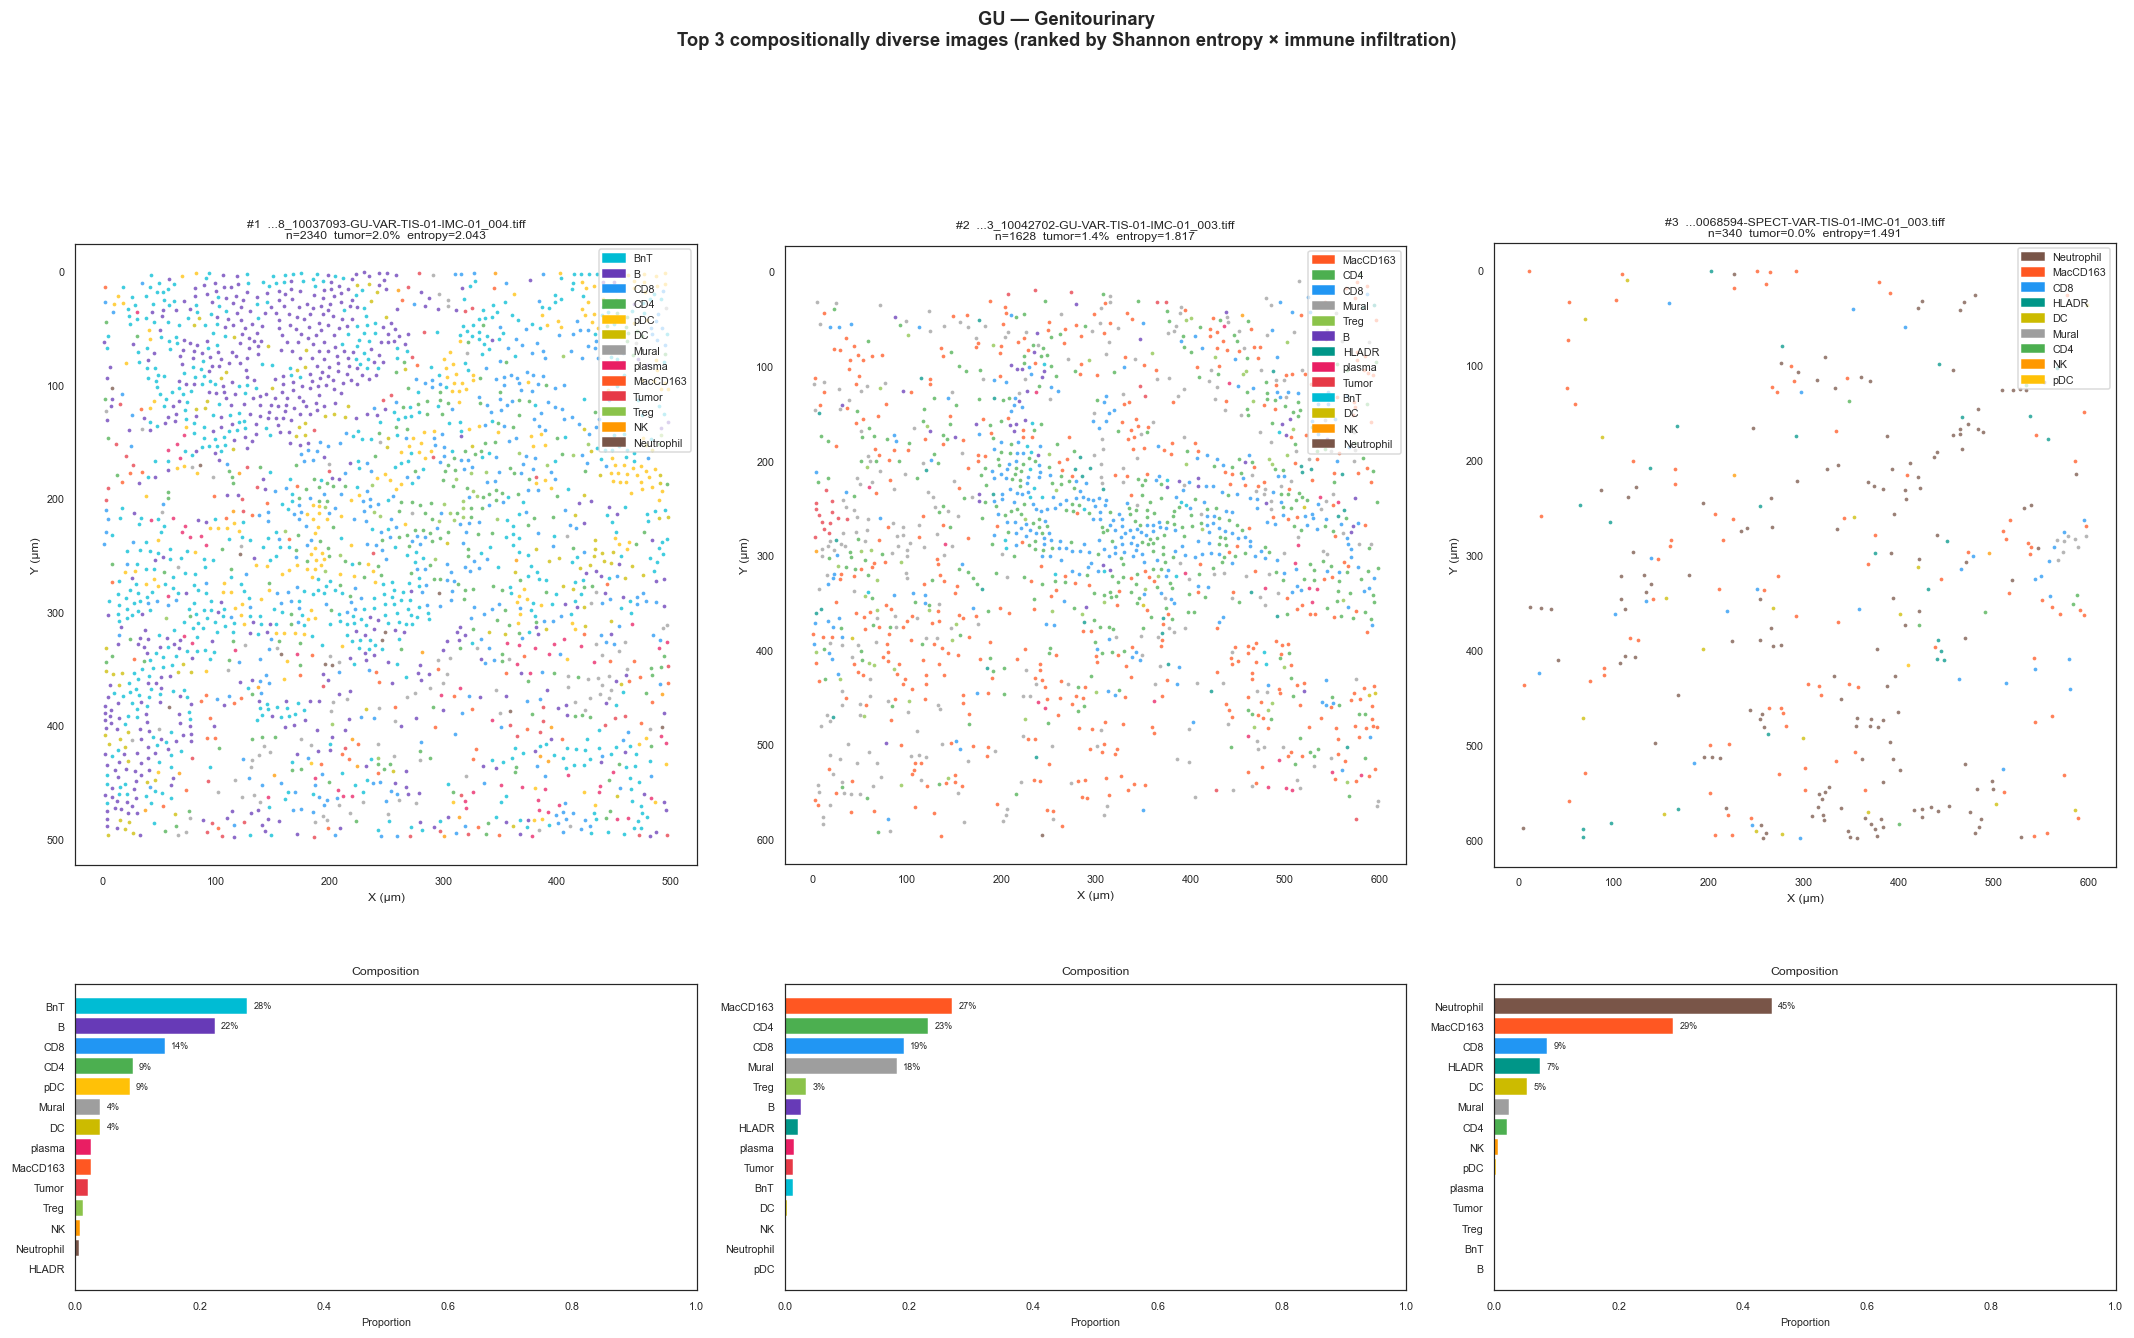

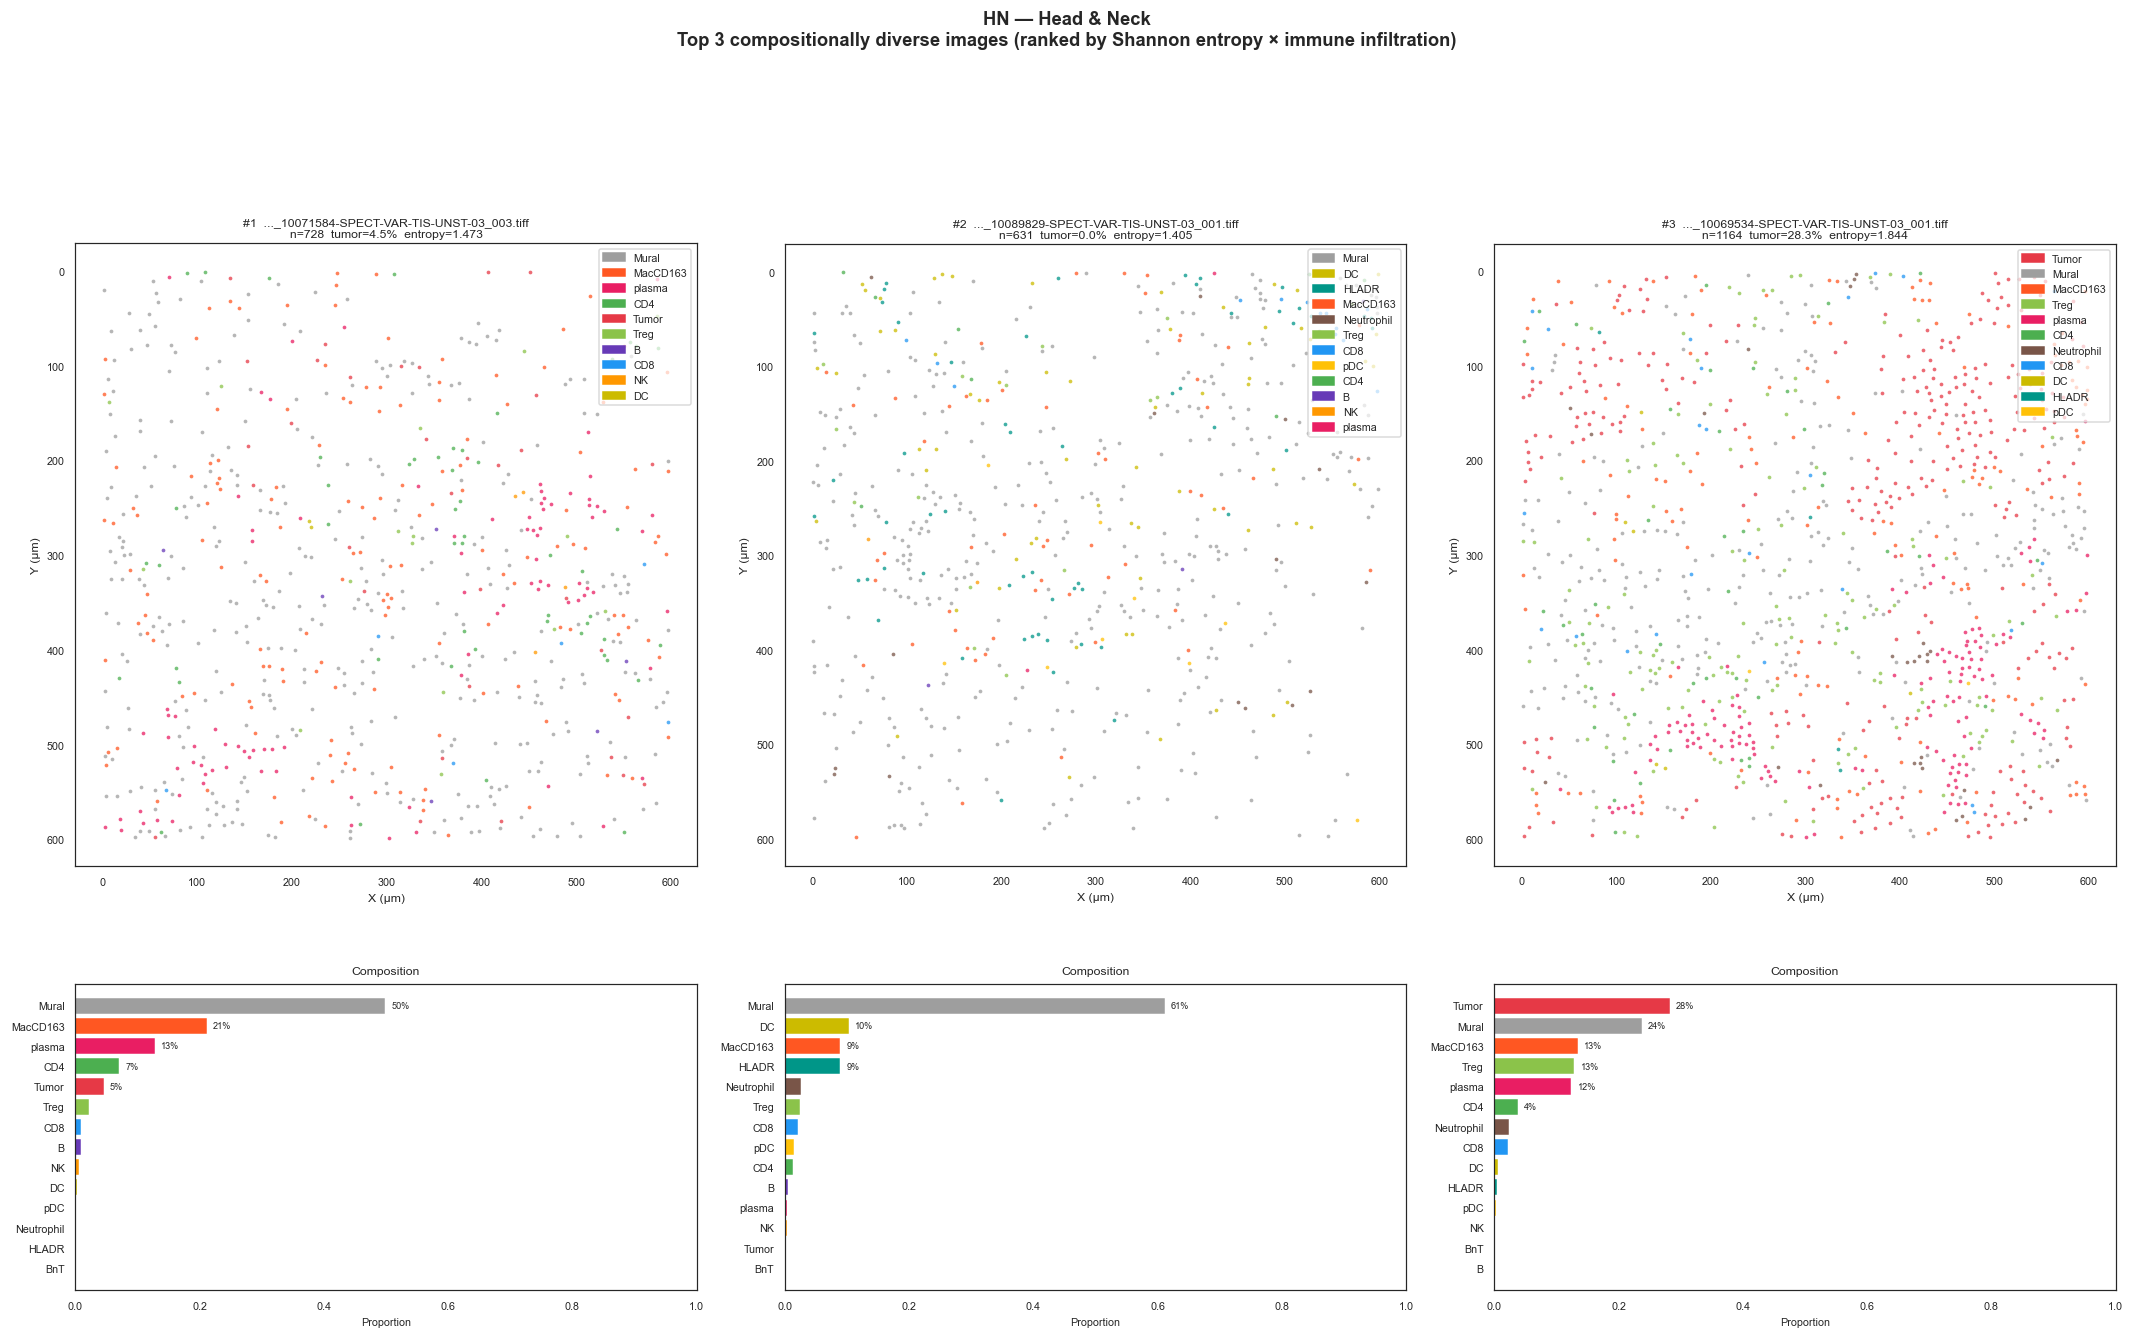

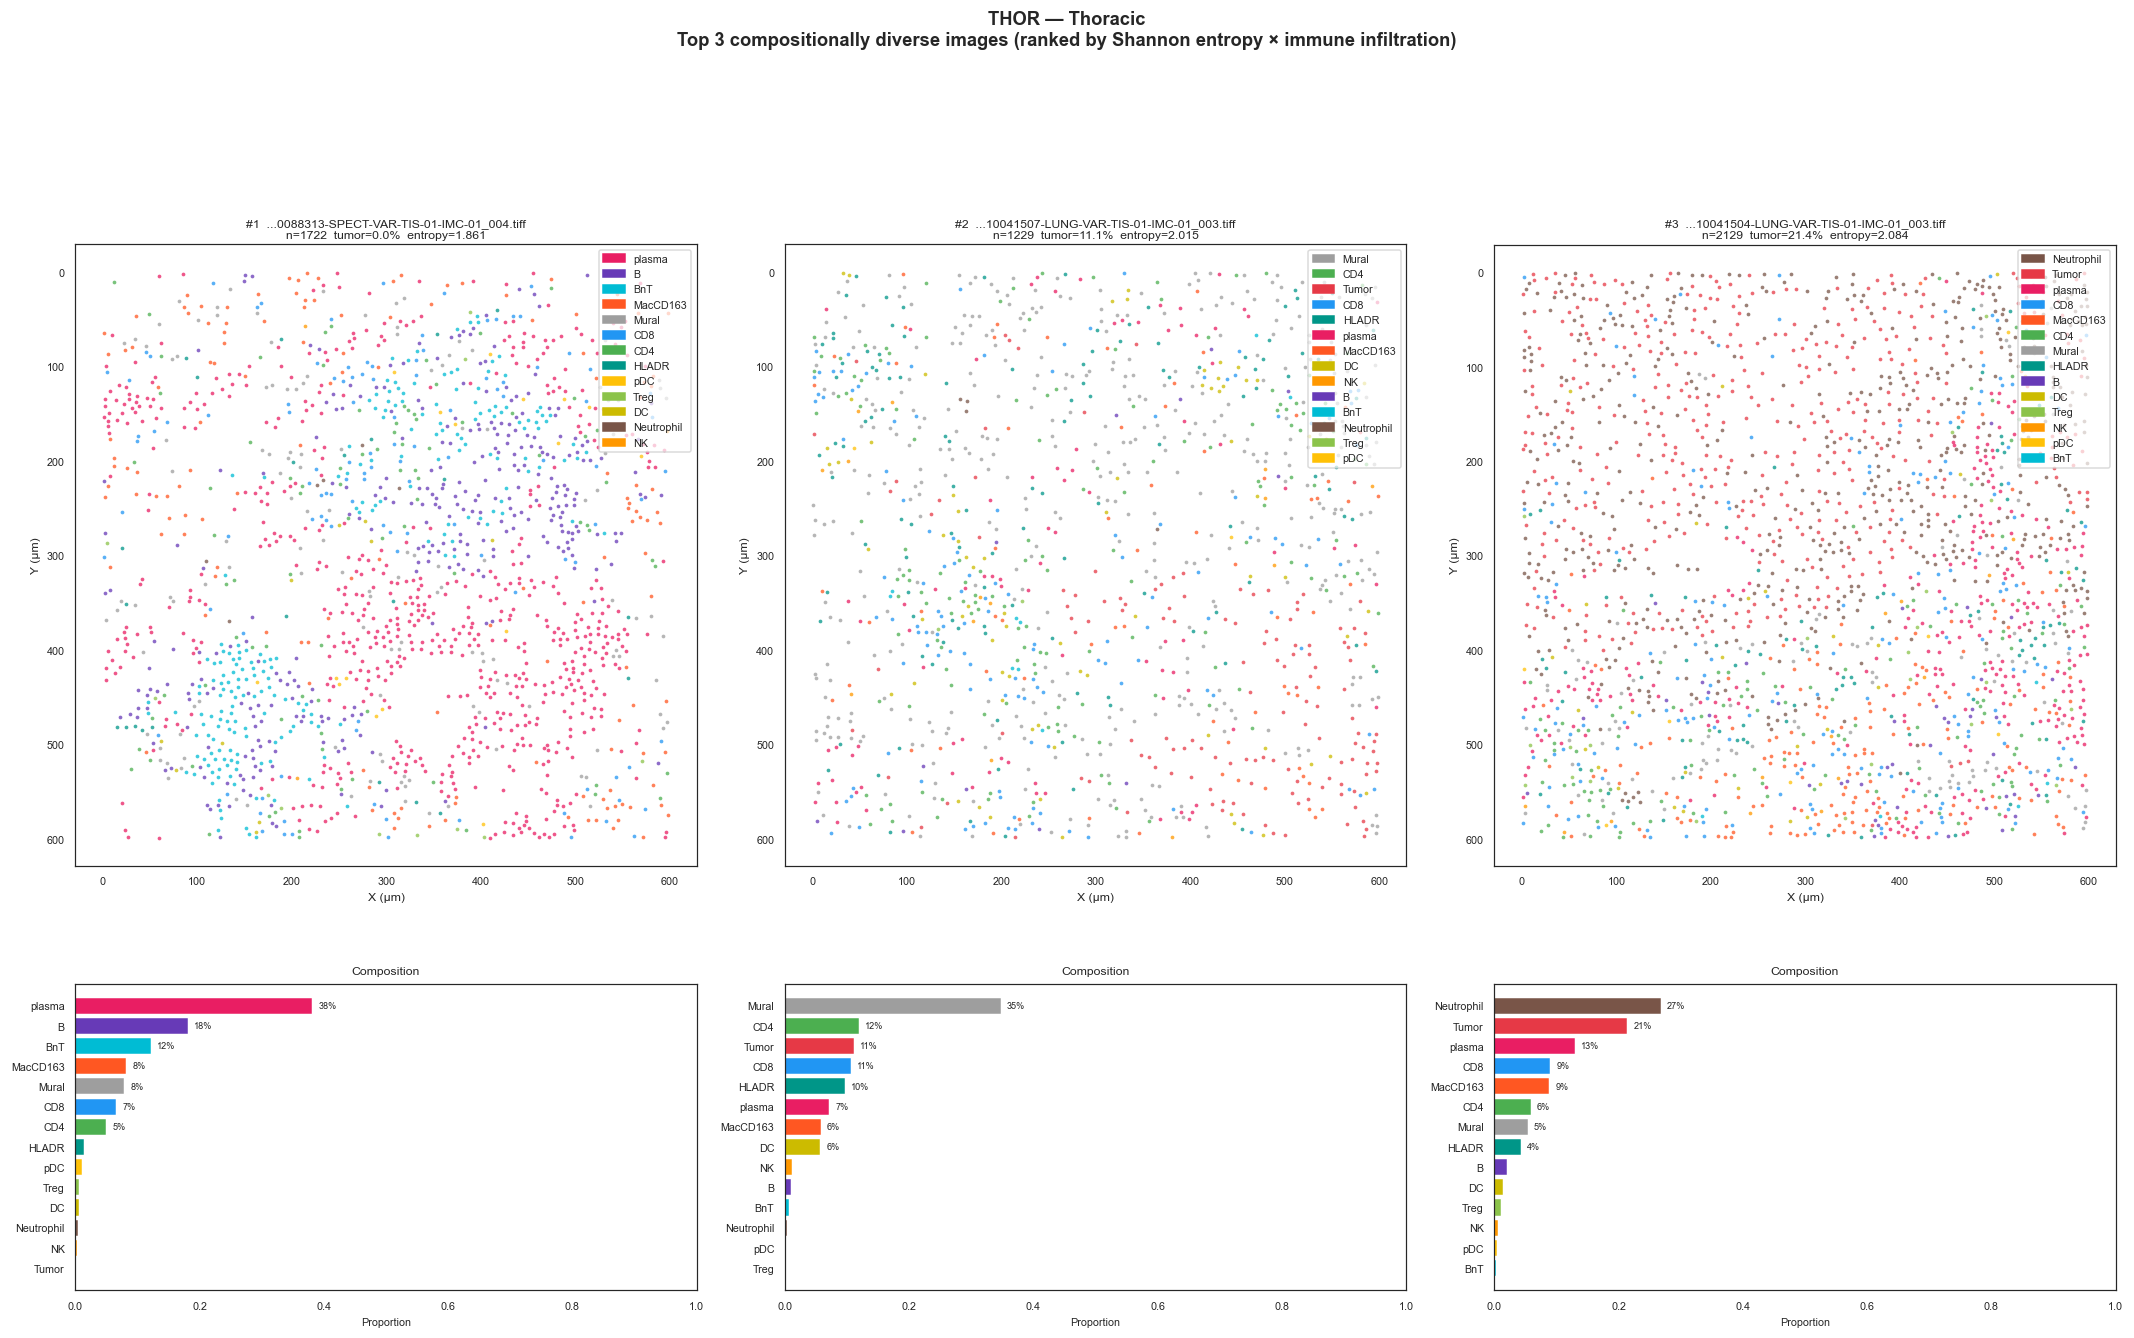

In [5]:
IND_LABELS = {
    'BREAS': 'BREAS — Breast cancer',
    'GI'   : 'GI — Gastrointestinal',
    'GU'   : 'GU — Genitourinary',
    'HN'   : 'HN — Head & Neck',
    'THOR' : 'THOR — Thoracic',
}

for ind, entries in diverse_samples.items():
    n = len(entries)
    fig, axes = plt.subplots(2, n, figsize=(6.5 * n, 12),
                             gridspec_kw={'height_ratios': [3, 1]})
    for col, entry in enumerate(entries):
        img = entry['image']
        adata_img = adata[adata.obs['image'] == img]
        short = ('...' + img[-40:]) if len(img) > 43 else img
        title = (f"#{entry['rank']}  {short}\n"
                 f"n={entry['n_cells']}  tumor={entry['tumor_prop']:.1%}  "
                 f"entropy={entry['shannon_entropy']:.3f}")
        plot_spatial_image(adata_img, axes[0, col], title=title, show_legend=True)
        plot_composition_bar(img, axes[1, col])
    fig.suptitle(
        f"{IND_LABELS[ind]}\nTop 3 compositionally diverse images "
        f"(ranked by Shannon entropy × immune infiltration)",
        fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    print()

---
## Part 5: Cross-Indication Overview — Best Sample per Cancer Type

The #1-ranked image from each indication on a single figure for quick cross-cancer comparison.

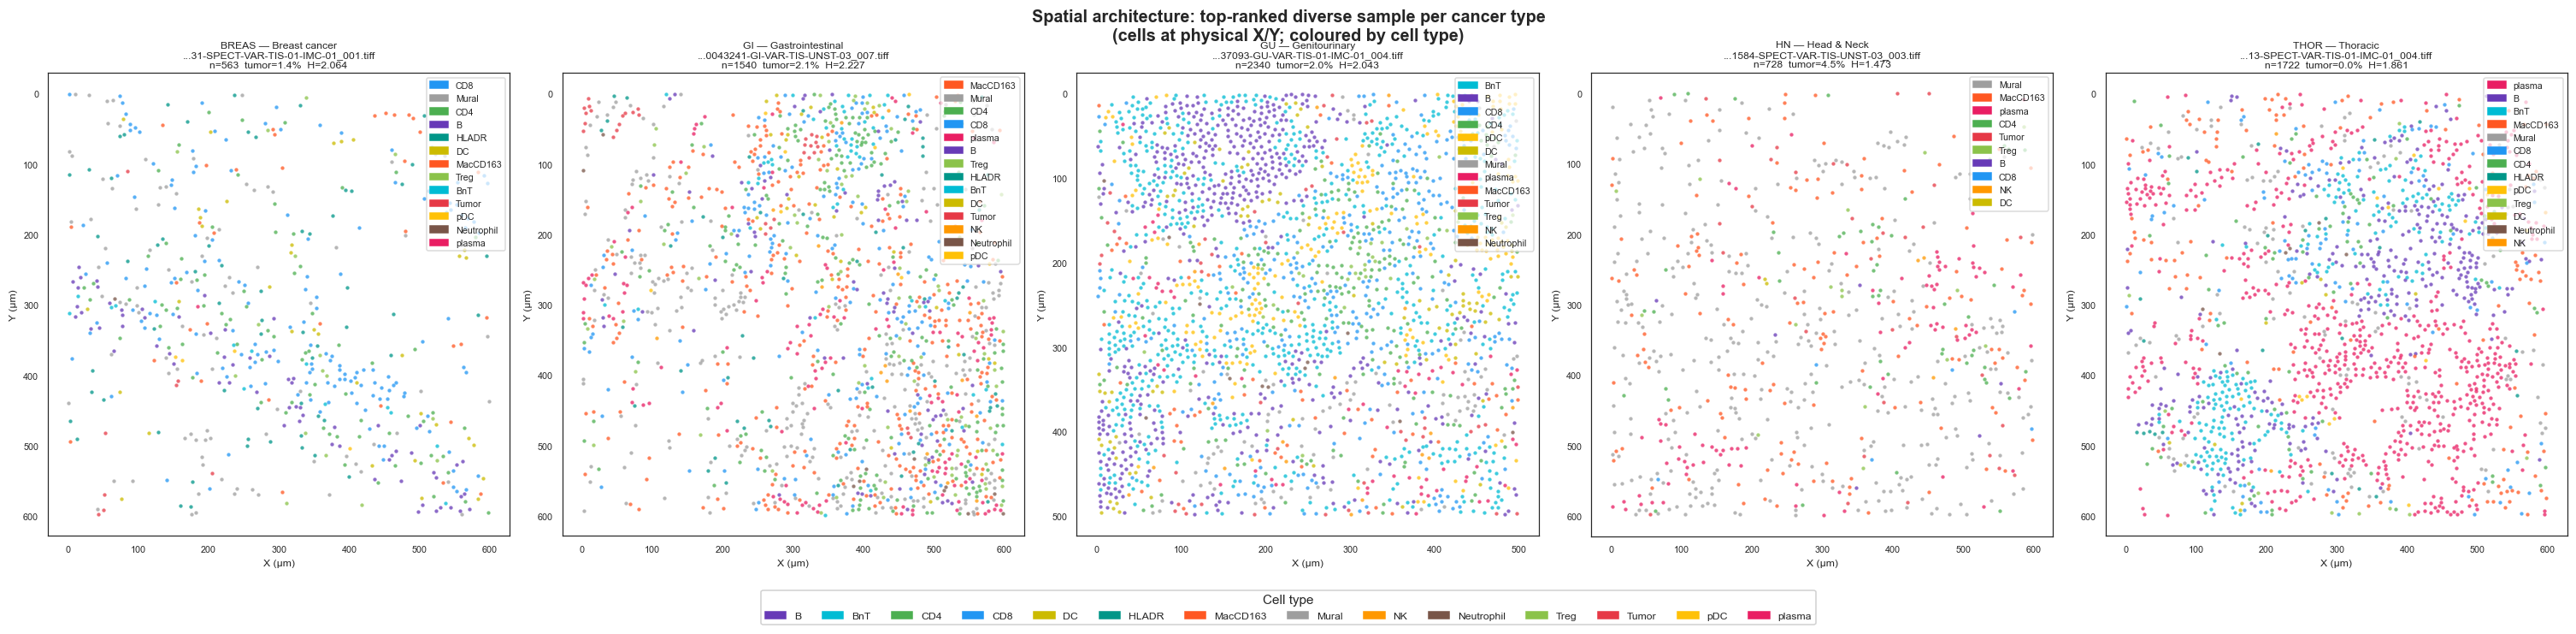

In [6]:
indications = list(diverse_samples.keys())
fig, axes = plt.subplots(1, len(indications), figsize=(5.5 * len(indications), 6))

for ax, ind in zip(axes, indications):
    entry = diverse_samples[ind][0]
    img   = entry['image']
    adata_img = adata[adata.obs['image'] == img]
    short = ('...' + img[-35:]) if len(img) > 38 else img
    title = (f"{IND_LABELS[ind]}\n{short}\n"
             f"n={entry['n_cells']}  tumor={entry['tumor_prop']:.1%}  H={entry['shannon_entropy']:.3f}")
    plot_spatial_image(adata_img, ax, title=title, show_legend=True, point_size=8)

cts_shown = set()
for ind in indications:
    img = diverse_samples[ind][0]['image']
    cts_shown |= set(adata.obs.loc[adata.obs['image'] == img, 'celltypes'].unique())
handles = [mpatches.Patch(color=CT_PALETTE[ct], label=ct) for ct in sorted(cts_shown)]
fig.legend(handles=handles, title='Cell type', fontsize=8,
           loc='lower center', ncol=len(cts_shown),
           bbox_to_anchor=(0.5, -0.12), framealpha=0.9)
fig.suptitle('Spatial architecture: top-ranked diverse sample per cancer type\n'
             '(cells at physical X/Y; coloured by cell type)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 6: Zoom-In on Immune Microenvironment

Zoom into the centre of the BREAS #1 image (most immune-infiltrated: 1.4% tumor) to reveal fine-scale cell mixing.

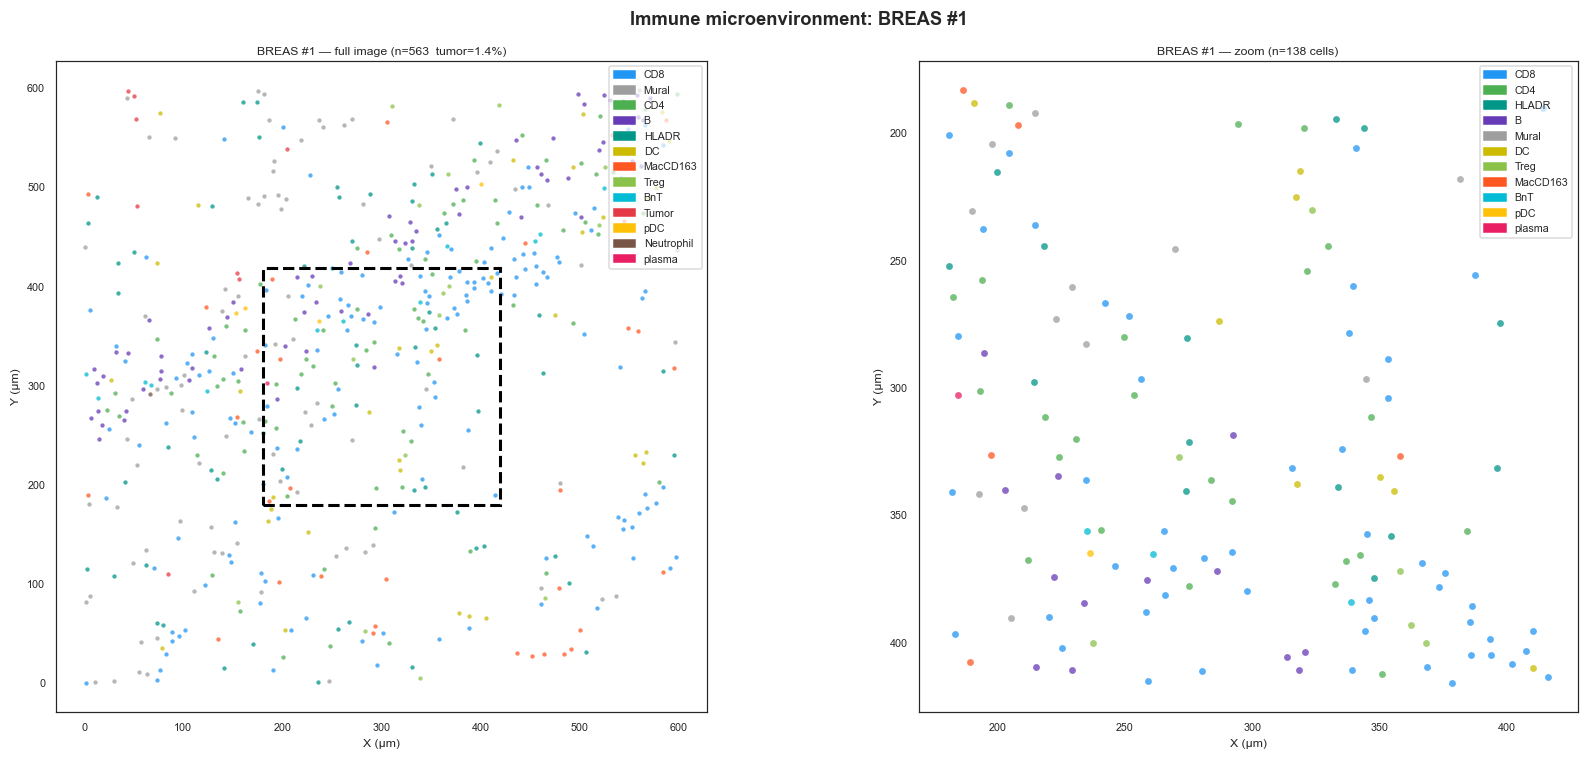

Cell type breakdown in zoom region:
celltypes
CD8           51
CD4           24
HLADR         14
B             13
Mural         12
DC             8
Treg           6
MacCD163       5
BnT            3
pDC            1
plasma         1
NK             0
Neutrophil     0
Tumor          0


In [7]:
entry_breas1 = diverse_samples['BREAS'][0]
img_breas1   = entry_breas1['image']
obs_breas1   = adata.obs[adata.obs['image'] == img_breas1]

x_min, x_max = obs_breas1['Pos_X'].min(), obs_breas1['Pos_X'].max()
y_min, y_max = obs_breas1['Pos_Y'].min(), obs_breas1['Pos_Y'].max()
x_mid, y_mid = (x_min + x_max) / 2, (y_min + y_max) / 2
x_range, y_range = x_max - x_min, y_max - y_min

zoom_x1, zoom_x2 = x_mid - 0.2 * x_range, x_mid + 0.2 * x_range
zoom_y1, zoom_y2 = y_mid - 0.2 * y_range, y_mid + 0.2 * y_range

obs_zoom = obs_breas1[
    obs_breas1['Pos_X'].between(zoom_x1, zoom_x2) &
    obs_breas1['Pos_Y'].between(zoom_y1, zoom_y2)
]
adata_zoom = adata[obs_zoom.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

adata_breas1 = adata[adata.obs['image'] == img_breas1]
plot_spatial_image(adata_breas1, axes[0],
    title=(f'BREAS #1 — full image '
           f'(n={entry_breas1["n_cells"]}  tumor={entry_breas1["tumor_prop"]:.1%})'),
    show_legend=True, point_size=8)
rect = plt.Rectangle((zoom_x1, zoom_y1), zoom_x2 - zoom_x1, zoom_y2 - zoom_y1,
                      linewidth=2, edgecolor='black', facecolor='none', linestyle='--')
axes[0].add_patch(rect)
axes[0].invert_yaxis()

plot_spatial_image(adata_zoom, axes[1],
    title=f'BREAS #1 — zoom (n={len(obs_zoom)} cells)',
    show_legend=True, point_size=20)

plt.suptitle('Immune microenvironment: BREAS #1', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('Cell type breakdown in zoom region:')
print(obs_zoom['celltypes'].value_counts().to_string())

---
## Part 7: Spatial Density (KDE) of Top Cell Types

KDE contours show where each cell type is spatially concentrated — useful for detecting immune clusters or exclusion zones.

GI #1 top 3 cell types: ['MacCD163', 'Mural', 'CD4']


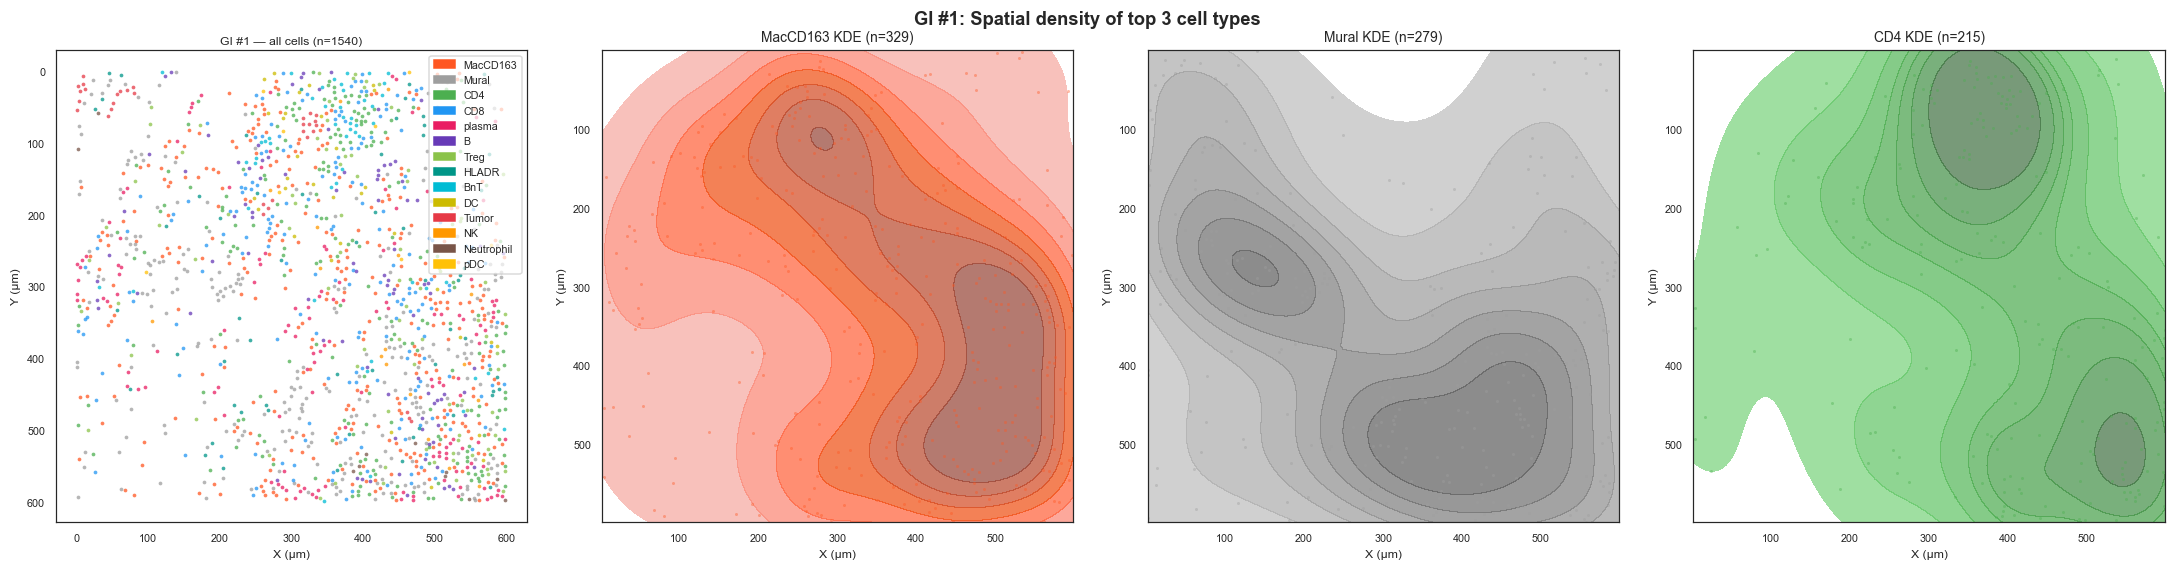

In [8]:
entry_gi1 = diverse_samples['GI'][0]
img_gi1   = entry_gi1['image']
obs_gi1   = adata.obs[adata.obs['image'] == img_gi1]
top3_ct   = obs_gi1['celltypes'].value_counts().head(3).index.tolist()
print(f'GI #1 top 3 cell types: {top3_ct}')

fig, axes = plt.subplots(1, len(top3_ct) + 1, figsize=(5 * (len(top3_ct) + 1), 5))

adata_gi1 = adata[adata.obs['image'] == img_gi1]
plot_spatial_image(adata_gi1, axes[0],
    title=f'GI #1 — all cells (n={entry_gi1["n_cells"]})',
    show_legend=True, point_size=6)

for ax, ct in zip(axes[1:], top3_ct):
    obs_ct = obs_gi1[obs_gi1['celltypes'] == ct]
    if len(obs_ct) >= 5:
        sns.kdeplot(x=obs_ct['Pos_X'], y=obs_ct['Pos_Y'], ax=ax,
                    fill=True, alpha=0.7, color=CT_PALETTE.get(ct, 'grey'),
                    levels=8, thresh=0.05)
        ax.scatter(obs_ct['Pos_X'], obs_ct['Pos_Y'],
                   c=CT_PALETTE.get(ct, 'grey'), s=4, alpha=0.4,
                   linewidths=0, rasterized=True)
    ax.set_xlim(obs_gi1['Pos_X'].min(), obs_gi1['Pos_X'].max())
    ax.set_ylim(obs_gi1['Pos_Y'].min(), obs_gi1['Pos_Y'].max())
    ax.invert_yaxis(); ax.set_aspect('equal')
    ax.set_title(f'{ct} KDE (n={len(obs_ct)})', fontsize=9)
    ax.set_xlabel('X (µm)', fontsize=8); ax.set_ylabel('Y (µm)', fontsize=8)
    ax.tick_params(labelsize=7)

fig.suptitle('GI #1: Spatial density of top 3 cell types', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Summary

| Section | Key take-away |
|---------|---------------|
| Part 4 | 15 curated diverse images — each cancer type shows distinct immune microenvironment architecture |
| Part 5 | Side-by-side comparison: BREAS/GI/GU have richer T-cell infiltration than HN |
| Part 6 | Zoom-in reveals fine-scale immune cell mixing invisible at full-image scale |
| Part 7 | KDE density maps quantify spatial clustering of specific cell types |

**Next:** Tutorial 3 (Squidpy) will formalise spatial relationships using neighbourhood graphs, co-occurrence scores, and Moran’s I.

---